In [1]:
# ============================================
# 1. ЗАГРУЗКА НЕОБХОДИМЫХ ВЕРСИЙ БИБЛИОТЕК
# ============================================

!pip install albumentations
!pip install --upgrade numpy pandas matplotlib seaborn

#!pip uninstall torch torchvision torchaudio -y
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
#!pip install tensorflow onnx onnx-tf

  Using cached numpy-2.2.6-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp313-cp313-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires pandas<3,>=1.4.0, but you have pandas 3.0.1 which is incompatible.


  Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl (12.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.2 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.2 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.2 which is incompatible.
openvino 2025.4.1 requires numpy<2.4.0,>=1.16.6, but you have numpy 2.4.2 which is incompatible.
streamlit 1.51.0 requires pandas<3,>=1.4.0, but you have pandas 3.0.1 which is incompatible.


In [1]:
# ============================================
# 2. ИМПОРТ НЕОБХОДИМЫХ БИБЛИОТЕК
# ============================================

import os
import cv2
import numpy as np
import random
import warnings
from tqdm import tqdm
import seaborn as sns
import shutil
from pathlib import Path
from collections import defaultdict

import albumentations as A
from albumentations.pytorch import ToTensorV2

from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torchvision import datasets

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

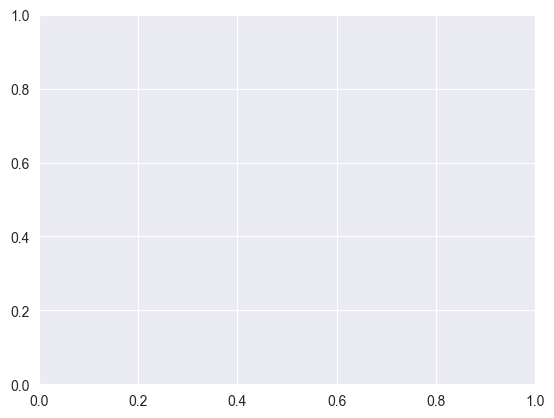

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots()

In [4]:
# ============================================
# 3. ПРОВЕРКА АППАРАТНЫХ РЕСУРСОВ
# ============================================
print(f"PyTorch версия: {torch.__version__}")
print(f"CUDA доступна: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU память: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch версия: 2.7.1+cu118
CUDA доступна: True
GPU: NVIDIA GeForce RTX 4060 Ti
GPU память: 8.59 GB


In [5]:
# ============================================
# 4. ЗАГРУЗКА ДАТАСЕТА KITTY
# ============================================

training_data = datasets.Kitti(
    root='data',
    train=True,
    download=True,
    transform=v2.ToTensor(),
)

test_data = datasets.Kitti(
    root='data',
    train=False,
    download=True,
    transform=v2.ToTensor(),
)

100%|██████████| 12.6G/12.6G [45:51<00:00, 4.57MB/s]  
100%|██████████| 5.60M/5.60M [00:01<00:00, 4.35MB/s]


In [6]:
len(training_data)

7481

In [7]:
# ============================================
# 5. СОЗДАНИЕ НЕОБХОДИМЫХ АССОЦИАЦИЙ
# ============================================

KITTI_DIR = "data/Kitti/raw"
IMAGE_DIR = os.path.join(KITTI_DIR, "training/image_2")
LABEL_DIR = os.path.join(KITTI_DIR, "training/label_2")
OUTPUT_IMAGE_DIR = "data/kitti_for_yolo/images"
OUTPUT_LABEL_DIR = "data/kitti_for_yolo/labels"

# Классы KITTI, которые есть в исходном датасете
CLASSES = ['Car', 'Cyclist', 'DontCare', 'Misc', 'Pedestrian', 'Person_sitting', 'Tram', 'Truck', 'Van']
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}

In [8]:
# =============================================
# 6.ПРЕОБРАЗОВАНИЕ LABELS В НУЖНЫЙ ФОРМАТ
# =============================================

def kitti_to_yolo(kitti_label_path, output_dir, img_width, img_height):
    """
    Конвертирует аннотации KITTI в формат YOLOv8n_base:
    <class_id> <x_center> <y_center> <width> <height> (нормализованные)
    """
    os.makedirs(output_dir, exist_ok=True)

    with open(kitti_label_path, 'r') as f:
        lines = f.readlines()

    labels = []
    yolo_lines = []
    for line in lines:
        parts = line.strip().split()
        class_name = parts[0]
        
        # Используем все классы KITTY, кроме Person_sitting и DontCare
        if class_name == 'Person_sitting':
            class_name = 'Pedestrian'
        if class_name == 'DontCare':
            continue

        # Классы KITTI приводим к стандарту YOLOv8n_base
        class_id = CLASS_TO_IDX[class_name]
        labels.append(class_id)

        x_min, y_min, x_max, y_max = map(float, parts[4:8])

        # Нормализация координат
        x_center = ((x_min + x_max) / 2) / img_width
        y_center = ((y_min + y_max) / 2) / img_height
        width = (x_max - x_min) / img_width
        height = (y_max - y_min) / img_height

        yolo_lines.append(f"{class_id} {x_center} {y_center} {width} {height}\n")

    # Сохраняем в файл
    output_path = os.path.join(output_dir, os.path.basename(kitti_label_path))
    with open(output_path, 'w') as f:
        f.writelines(yolo_lines)

    return labels

In [9]:
img_names = os.listdir(IMAGE_DIR)
label_names = os.listdir(LABEL_DIR)
label_distribution = []

for i in range(7481):
    img = Image.open(os.path.join(IMAGE_DIR, img_names[i]))
    img_width, img_height = img.size
    label_distribution.extend(kitti_to_yolo(os.path.join(LABEL_DIR, label_names[i]), OUTPUT_LABEL_DIR, img_width, img_height))

In [21]:
torch.save(label_distribution, 'data/label_distribution.pth')

In [23]:
label_distribution = torch.load('data/label_distribution.pth', weights_only=True)

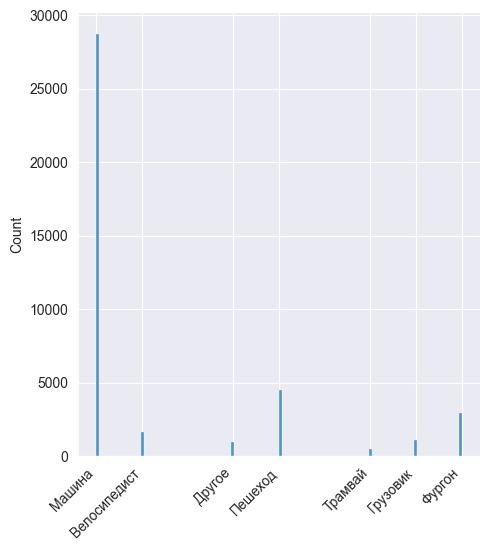

In [10]:
sns.displot(np.array(label_distribution))

plt.xticks(ticks=[0, 1, 3, 4, 6, 7, 8], labels=['Машина', 'Велосипедист', 'Другое', 'Пешеход', 'Трамвай', 'Грузовик', 'Фургон'])
plt.xticks(rotation=45, ha='right')

plt.show()

In [11]:
# ============================================
# 7. РАСПРЕДЕЛЕНИЕ НА TRAIN И TEST
# ============================================

def create_train_test_loaders(test_size=0.2):
    # Разделение на train/test
    all_images = [f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')]
    train_images, test_images = train_test_split(all_images, test_size=test_size, random_state=42)

    # Создаем папки для train/test
    os.makedirs(os.path.join(OUTPUT_LABEL_DIR, "train"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_LABEL_DIR, "val"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_IMAGE_DIR, "train"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_IMAGE_DIR, "val"), exist_ok=True)

    # Копируем аннотации в соответствующие папки
    for img in train_images:
        label = img.replace('.png', '.txt')
        os.rename(
            os.path.join(OUTPUT_LABEL_DIR, label),
            os.path.join(OUTPUT_LABEL_DIR, "train", label))

    for img in test_images:
        label = img.replace('.png', '.txt')
        os.rename(
            os.path.join(OUTPUT_LABEL_DIR, label),
            os.path.join(OUTPUT_LABEL_DIR, "val", label))

    for img in train_images:
        os.rename(
            os.path.join(OUTPUT_IMAGE_DIR, img),
            os.path.join(OUTPUT_IMAGE_DIR, "train", img))

    for img in test_images:
        os.rename(
            os.path.join(OUTPUT_IMAGE_DIR, img),
            os.path.join(OUTPUT_IMAGE_DIR, "val", img))

create_train_test_loaders()

In [12]:
# ============================================
# 8. АУГМЕНТАЦИЯ ИЗОБРАЖЖЕНИЙ
# ============================================

class DatasetBalancer:
    def __init__(self, dataset_path, target_augmentations_per_class=None):
        """
        Args:
            dataset_path: путь к корневой папке датасета
            target_augmentations_per_class: словарь {class_name: target_count}
        """
        self.dataset_path = Path(dataset_path)
        
        # ИСПРАВЛЕНО: правильная структура для KITTI датасета
        self.train_images_path = self.dataset_path / 'images' / 'train'
        self.train_labels_path = self.dataset_path / 'labels' / 'train'
        
        # Проверяем существование путей
        print(f"Проверка путей:")
        print(f"  Images: {self.train_images_path}")
        print(f"  Labels: {self.train_labels_path}")
        
        if not self.train_images_path.exists():
            raise FileNotFoundError(f"Папка не найдена: {self.train_images_path}")
        if not self.train_labels_path.exists():
            raise FileNotFoundError(f"Папка не найдена: {self.train_labels_path}")
        
        # Создаем папки для аугментированных данных
        self.augmented_images_path = self.train_images_path / 'augmented'
        self.augmented_labels_path = self.train_labels_path / 'augmented'
        
        # Создаем папки
        self.augmented_images_path.mkdir(parents=True, exist_ok=True)
        self.augmented_labels_path.mkdir(parents=True, exist_ok=True)
        
        print(f"\nПапки для аугментированных данных созданы:")
        print(f"  Images: {self.augmented_images_path}")
        print(f"  Labels: {self.augmented_labels_path}")
        
        # ИСПРАВЛЕНО: ваши классы с правильными индексами
        self.class_names = {
            0: 'Машина',  # Машина (29000)
            1: 'Велосипедист',  # Велосипедист (1500)
            3: 'Другое',  # Другое (1000)
            4: 'Пешеход',  # Пешеход (4800)
            6: 'Трамвай',  # Трамвай (500)
            7: 'Грузовик',  # Грузовик (800)
            8: 'Фургон',  # Фургон (3000)
        }
        
        # Целевое количество для каждого класса
        self.target_counts = target_augmentations_per_class or {
            'Машина': 30000,        # немного увеличиваем
            'Велосипедист': 10000,    # сильно увеличиваем
            'Другое': 10000,       # сильно увеличиваем
            'Пешеход': 15000, # умеренно увеличиваем
            'Трамвай': 10000,       # сильно увеличиваем
            'Грузовик': 10000,      # сильно увеличиваем
            'Фургон': 10000,        # сильно увеличиваем
        }
        
        # Счетчики для статистики
        self.stats = {
            'total_images': 0,
            'images_with_objects': 0,
            'objects_by_class': defaultdict(int),
            'images_by_class': defaultdict(int)
        }
        
    def parse_yolo_label(self, label_path):
        """Парсинг YOLOv8n_base формата labels"""
        boxes = []
        classes = []
        
        if not os.path.exists(label_path):
            return boxes, classes
        
        try:
            with open(label_path, 'r') as f:
                for line_num, line in enumerate(f.readlines()):
                    data = line.strip().split()
                    if len(data) >= 5:
                        try:
                            class_id = int(data[0])
                            # Проверяем, что класс в допустимом диапазоне
                            if class_id in self.class_names:
                                bbox = [float(x) for x in data[1:5]]
                                # Проверяем, что bbox корректен
                                if all(0 <= x <= 1 for x in bbox):
                                    boxes.append(bbox)
                                    classes.append(class_id)
                                else:
                                    print(f"  Предупреждение: некорректный bbox в {label_path.name}, строка {line_num}")
                            else:
                                print(f"  Предупреждение: неизвестный класс {class_id} в {label_path.name}")
                        except (ValueError, IndexError) as e:
                            print(f"  Ошибка парсинга в {label_path.name}, строка {line_num}: {e}")
        except Exception as e:
            print(f"Ошибка при чтении {label_path}: {e}")
        
        return boxes, classes
    
    def analyze_dataset(self):
        """Детальный анализ датасета"""
        print("\n" + "="*50)
        print("АНАЛИЗ ДАТАСЕТА")
        print("="*50)
        
        # Получаем все файлы разметки
        label_files = list(self.train_labels_path.glob('*.txt'))
        # Исключаем папку augmented
        label_files = [f for f in label_files if 'augmented' not in str(f)]
        
        print(f"Найдено файлов разметки: {len(label_files)}")
        
        if len(label_files) == 0:
            print("❌ Нет файлов разметки! Проверьте путь:")
            print(f"   {self.train_labels_path}")
            return False
        
        # Анализируем каждый файл
        images_with_objects = 0
        
        for label_file in tqdm(label_files, desc="Анализ файлов"):
            self.stats['total_images'] += 1
            boxes, classes = self.parse_yolo_label(label_file)
            
            if classes:
                images_with_objects += 1
                unique_classes = set(classes)
                
                for class_id in classes:
                    self.stats['objects_by_class'][class_id] += 1
                
                for class_id in unique_classes:
                    self.stats['images_by_class'][class_id] += 1
        
        self.stats['images_with_objects'] = images_with_objects
        
        # Выводим статистику
        print(f"\n📊 СТАТИСТИКА ДАТАСЕТА:")
        print(f"   Всего изображений: {self.stats['total_images']}")
        print(f"   Изображений с объектами: {self.stats['images_with_objects']}")
        print(f"   Пустых изображений: {self.stats['total_images'] - self.stats['images_with_objects']}")
        
        print(f"\n📊 РАСПРЕДЕЛЕНИЕ ОБЪЕКТОВ ПО КЛАССАМ:")
        total_objects = sum(self.stats['objects_by_class'].values())
        
        for class_id, class_name in sorted(self.class_names.items()):
            count = self.stats['objects_by_class'].get(class_id, 0)
            percentage = (count / total_objects * 100) if total_objects > 0 else 0
            images_count = self.stats['images_by_class'].get(class_id, 0)
            
            # Визуальная шкала
            bar_length = int(percentage / 2)
            bar = "█" * bar_length + "░" * (50 - bar_length)
            
            print(f"   {class_name} (ID:{class_id}):")
            print(f"     Объектов: {count:6d} ({percentage:5.2f}%)")
            print(f"     Изображений: {images_count:6d}")
            print(f"     {bar}")
        
        return True
    
    def create_augmentation_pipeline(self, intensity='normal'):
        """Создание пайплайна аугментации"""
        if intensity == 'intense':
            return A.Compose([
                A.RandomRotate90(p=0.7),
                A.HorizontalFlip(p=0.7),
                A.VerticalFlip(p=0.4),
                A.Transpose(p=0.4),
                A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.8),
                A.HueSaturationValue(hue_shift_limit=30, sat_shift_limit=40, val_shift_limit=30, p=0.7),
                A.RandomGamma(gamma_limit=(70, 130), p=0.7),
                A.Blur(blur_limit=5, p=0.5),
                A.GaussNoise(var_limit=(20.0, 50.0), p=0.5),
                A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=0.5),
                A.RandomShadow(p=0.3),
                A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=0.2),
            ], bbox_params=A.BboxParams(
                format='yolo',
                label_fields=['class_labels'],
                min_visibility=0.3
            ))
        else:
            return A.Compose([
                A.RandomRotate90(p=0.5),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.2),
                A.Transpose(p=0.2),
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7),
                A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
                A.RandomGamma(gamma_limit=(80, 120), p=0.5),
                A.Blur(blur_limit=3, p=0.3),
                A.GaussNoise(var_limit=(10.0, 30.0), p=0.3),
            ], bbox_params=A.BboxParams(
                format='yolo',
                label_fields=['class_labels'],
                min_visibility=0.3
            ))
        
    def find_images_for_classes(self):
        """Поиск изображений по классам"""
        images_by_class = defaultdict(list)
        label_files = list(self.train_labels_path.glob('*.txt'))
        label_files = [f for f in label_files if 'augmented' not in str(f)]
        
        for label_file in tqdm(label_files, desc="Индексация изображений"):
            boxes, classes = self.parse_yolo_label(label_file)
            if classes:
                unique_classes = set(classes)
                for class_id in unique_classes:
                    images_by_class[class_id].append(label_file.stem)
        
        return images_by_class
    
    def augment_image(self, image_path, boxes, classes, aug_pipeline):
        """Аугментация одного изображения"""
        # Чтение изображения
        image = cv2.imread(str(image_path))
        if image is None:
            return None, None
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        try:
            # Применение аугментации
            augmented = aug_pipeline(
                image=image,
                bboxes=boxes,
                class_labels=classes
            )
            
            if len(augmented['bboxes']) == 0:
                return None, None
            
            # Конвертация обратно в BGR для сохранения
            aug_image = cv2.cvtColor(augmented['image'], cv2.COLOR_RGB2BGR)
            
            return aug_image, (augmented['bboxes'], augmented['class_labels'])
        except Exception as e:
            print(f"Ошибка при аугментации {image_path.name}: {e}")
            return None, None
        
    def balance_dataset(self):
        """Основной метод для балансировки датасета"""
        
        # Шаг 1: Анализ текущего состояния
        if not self.analyze_dataset():
            print("\n❌ Анализ датасета не удался. Прерывание.")
            return
        
        # Шаг 2: Расчет необходимых аугментаций
        print("\n" + "="*50)
        print("ПЛАНИРОВАНИЕ АУГМЕНТАЦИИ")
        print("="*50)
        
        aug_plan = {}
        for class_id, class_name in self.class_names.items():
            current = self.stats['objects_by_class'].get(class_id, 0)
            target = self.target_counts.get(class_name, current)
            
            if target > current and current > 0:
                multiplier = min(10, target / current)
                aug_plan[class_id] = {
                    'name': class_name,
                    'current': current,
                    'target': target,
                    'multiplier': multiplier,
                    'needed': int(target - current)
                }
                print(f"   {class_name}: {current} -> {target} (x{multiplier:.2f}, +{aug_plan[class_id]['needed']})")
            else:
                print(f"   {class_name}: {current} (достаточно)")
        
        # Шаг 3: Индексация изображений
        print("\n" + "="*50)
        print("ИНДЕКСАЦИЯ ИЗОБРАЖЕНИЙ")
        print("="*50)
        
        images_by_class = self.find_images_for_classes()
        
        for class_id, images in images_by_class.items():
            class_name = self.class_names.get(class_id, f"Unknown_{class_id}")
            print(f"   {class_name}: {len(images)} изображений")
        
        # Шаг 4: Аугментация
        print("\n" + "="*50)
        print("ЗАПУСК АУГМЕНТАЦИИ")
        print("="*50)
        
        normal_aug = self.create_augmentation_pipeline('normal')
        intense_aug = self.create_augmentation_pipeline('intense')
        
        aug_stats = defaultdict(int)
        
        for class_id, plan in aug_plan.items():
            if plan['needed'] <= 0:
                continue
            
            print(f"\n▶ Аугментация класса {plan['name']}:")
            print(f"   Нужно создать {plan['needed']} новых объектов")
            
            images_for_class = images_by_class.get(class_id, [])
            if not images_for_class:
                print(f"   ⚠ Нет изображений с классом {plan['name']}!")
                continue
            
            # Рассчитываем количество аугментаций на изображение
            augs_per_image = max(1, min(10, plan['needed'] // len(images_for_class) * 2))
            print(f"   Будем делать ~{augs_per_image} аугментаций на изображение")
            
            created = 0
            attempts = 0
            max_attempts = plan['needed'] * 3  # Защита от бесконечного цикла
            
            progress_bar = tqdm(total=plan['needed'], desc=f"   Прогресс")
            
            while created < plan['needed'] and attempts < max_attempts:
                attempts += 1
                
                # Выбираем случайное изображение с нужным классом
                img_name = random.choice(images_for_class)
                img_path = self.train_images_path / f"{img_name}.png"
                label_path = self.train_labels_path / f"{img_name}.txt"
                
                if not img_path.exists() or not label_path.exists():
                    continue
                
                boxes, classes = self.parse_yolo_label(label_path)
                if not boxes:
                    continue
                
                # Выбираем интенсивность аугментации
                use_intense = plan['multiplier'] > 5 and random.random() < 0.5
                aug_pipeline = intense_aug if use_intense else normal_aug
                
                # Применяем аугментацию
                aug_image, (aug_boxes, aug_classes) = self.augment_image(
                    img_path, boxes, classes, aug_pipeline
                )
                
                if aug_image is None:
                    continue
                
                # Сохраняем результат
                aug_name = f"{img_name}_aug_{created}"
                aug_img_path = self.augmented_images_path / f"{aug_name}.png"
                aug_label_path = self.augmented_labels_path / f"{aug_name}.txt"
                
                cv2.imwrite(str(aug_img_path), aug_image)
                
                with open(aug_label_path, 'w') as f:
                    for bbox, cls in zip(aug_boxes, aug_classes):
                        f.write(f"{int(cls)} {' '.join(map(str, bbox))}\n")
                        aug_stats[cls] += 1
                        
                        # Учитываем только объекты нужного класса для счетчика
                        if cls == class_id:
                            created += 1
                            progress_bar.update(1)
            
            progress_bar.close()
            print(f"   Создано {created} объектов класса {plan['name']}")
        
        # Шаг 5: Итоговая статистика
        print("\n" + "="*50)
        print("ИТОГИ АУГМЕНТАЦИИ")
        print("="*50)
        
        print("\nДобавлено объектов по классам:")
        for class_id, count in sorted(aug_stats.items()):
            class_name = self.class_names.get(class_id, f"Unknown_{class_id}")
            print(f"   {class_name}: +{count}")
        
        # Итоговое распределение
        print("\nНОВОЕ РАСПРЕДЕЛЕНИЕ (оригинал + аугментация):")
        total_original = sum(self.stats['objects_by_class'].values())
        total_new = sum(aug_stats.values())
        
        for class_id, class_name in sorted(self.class_names.items()):
            original = self.stats['objects_by_class'].get(class_id, 0)
            added = aug_stats.get(class_id, 0)
            new_total = original + added
            percentage = (new_total / (total_original + total_new) * 100) if (total_original + total_new) > 0 else 0
            print(f"   {class_name}: {original} +{added} = {new_total} ({percentage:.2f}%)")
        
        # Создаем YAML файл
        self.create_dataset_yaml()
        
    def create_dataset_yaml(self):
        """Создание файла dataset.yaml для YOLOv8n_base"""
        abs_path = self.dataset_path.absolute()
        
        yaml_content = f"""# Dataset for YOLOv8 training
                        path: {abs_path}
                        train: images/train
                        val: images/val

                        # Classes
                        nc: {len(self.class_names)}
                        names: {list(self.class_names.values())}
                        """
        
        yaml_path = self.dataset_path / 'dataset_augmented.yaml'
        with open(yaml_path, 'w') as f:
            f.write(yaml_content)
        
        print(f"\n✅ Создан файл конфигурации: {yaml_path}")
        print(f"   Для обучения используйте:")
        print(f"   yolo train data={yaml_path} model=yolov8n.pt epochs=100")
    

In [13]:
# Укажите путь к вашему датасету
DATASET_PATH = "data/kitti_for_yolo"

# Конвертируем в Path для корректной работы с путями
dataset_path = Path(DATASET_PATH)

print("="*50)
print("БАЛАНСИРОВКА ДАТАСЕТА KITTI")
print("="*50)
print(f"Путь к датасету: {dataset_path.absolute()}")

# Проверяем существование пути
if not dataset_path.exists():
    print(f"❌ Ошибка: Путь {dataset_path} не существует!")
else:
    balancer = DatasetBalancer(dataset_path)
    balancer.balance_dataset()

БАЛАНСИРОВКА ДАТАСЕТА KITTI
Путь к датасету: C:\Users\1\Documents\Stud BMSTU\8 semestr\VKR\VKR_project\data\kitti_for_yolo
Проверка путей:
  Images: data\kitti_for_yolo\images\train
  Labels: data\kitti_for_yolo\labels\train

Папки для аугментированных данных созданы:
  Images: data\kitti_for_yolo\images\train\augmented
  Labels: data\kitti_for_yolo\labels\train\augmented

АНАЛИЗ ДАТАСЕТА
Найдено файлов разметки: 5984


Анализ файлов: 100%|██████████| 5984/5984 [00:00<00:00, 14259.19it/s]



📊 СТАТИСТИКА ДАТАСЕТА:
   Всего изображений: 5984
   Изображений с объектами: 5984
   Пустых изображений: 0

📊 РАСПРЕДЕЛЕНИЕ ОБЪЕКТОВ ПО КЛАССАМ:
   Машина (ID:0):
     Объектов:  22853 (71.07%)
     Изображений:   5346
     ███████████████████████████████████░░░░░░░░░░░░░░░
   Велосипедист (ID:1):
     Объектов:   1319 ( 4.10%)
     Изображений:    919
     ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
   Другое (ID:3):
     Объектов:    786 ( 2.44%)
     Изображений:    622
     █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
   Пешеход (ID:4):
     Объектов:   3571 (11.11%)
     Изображений:   1420
     █████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
   Трамвай (ID:6):
     Объектов:    416 ( 1.29%)
     Изображений:    287
     ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
   Грузовик (ID:7):
     Объектов:    867 ( 2.70%)
     Изображений:    816
     █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
   Фургон (ID:8):
     Объектов:   2344 ( 7.29%)
     Изображен

Индексация изображений: 100%|██████████| 5984/5984 [00:00<00:00, 13406.80it/s]


   Машина: 5346 изображений
   Велосипедист: 919 изображений
   Грузовик: 816 изображений
   Другое: 622 изображений
   Пешеход: 1420 изображений
   Фургон: 1718 изображений
   Трамвай: 287 изображений

ЗАПУСК АУГМЕНТАЦИИ

▶ Аугментация класса Машина:
   Нужно создать 7147 новых объектов
   Будем делать ~2 аугментаций на изображение


...

   Создано 9584 объектов класса Трамвай

▶ Аугментация класса Грузовик:
   Нужно создать 9133 новых объектов
   Будем делать ~10 аугментаций на изображение


   Прогресс: 100%|██████████| 9133/9133 [17:29<00:00,  8.70it/s]  


   Создано 9133 объектов класса Грузовик

▶ Аугментация класса Фургон:
   Нужно создать 7656 новых объектов
   Будем делать ~8 аугментаций на изображение


   Прогресс: 7657it [03:14, 39.40it/s]                          

   Создано 7657 объектов класса Фургон

ИТОГИ АУГМЕНТАЦИИ

Добавлено объектов по классам:
   Машина: +144019
   Велосипедист: +15814
   Другое: +13467
   Пешеход: +29744
   Трамвай: +11181
   Грузовик: +13331
   Фургон: +23174

НОВОЕ РАСПРЕДЕЛЕНИЕ (оригинал + аугментация):
   Машина: 22853 +144019 = 166872 (58.99%)
   Велосипедист: 1319 +15814 = 17133 (6.06%)
   Другое: 786 +13467 = 14253 (5.04%)
   Пешеход: 3571 +29744 = 33315 (11.78%)
   Трамвай: 416 +11181 = 11597 (4.10%)
   Грузовик: 867 +13331 = 14198 (5.02%)
   Фургон: 2344 +23174 = 25518 (9.02%)

✅ Создан файл конфигурации: data\kitti_for_yolo\dataset_augmented.yaml
   Для обучения используйте:
   yolo train data=data\kitti_for_yolo\dataset_augmented.yaml model=yolov8n.pt epochs=100


In [14]:
# =====================================================
# 8.2. ИСПРАВЛЕНИЕ ОШИБКИ ПОРЯДКОВОГО НОМЕРА КЛАССОВ
# =====================================================

def remap_classes(base_path):
    """
    Перенумеровывает классы: 7→2, 8→5 во всех файлах разметки

    Args:
        base_path: корневой путь к датасету (data/kitti_for_yolo)
    """
    # Словарь для перекодировки: старый класс -> новый класс
    remap = {7: 2, 8: 5}

    # Проходим по train и val
    for split in ['train', 'val']:
        # Основная папка
        labels_dir = Path(base_path) / 'labels' / split
        for label_file in labels_dir.glob('*.txt'):
            with open(label_file, 'r') as f:
                lines = f.readlines()

            new_lines = []
            for line in lines:
                parts = line.strip().split()
                if parts:
                    class_id = int(float(parts[0]))
                    if class_id in remap:
                        parts[0] = str(remap[class_id])
                    new_lines.append(' '.join(parts) + '\n')

            with open(label_file, 'w') as f:
                f.writelines(new_lines)

        # Папка с аугментированными
        aug_dir = labels_dir / 'augmented'
        if aug_dir.exists():
            for label_file in aug_dir.glob('*.txt'):
                with open(label_file, 'r') as f:
                    lines = f.readlines()

                new_lines = []
                for line in lines:
                    parts = line.strip().split()
                    if parts:
                        class_id = int(float(parts[0]))
                        if class_id in remap:
                            parts[0] = str(remap[class_id])
                        new_lines.append(' '.join(parts) + '\n')

                with open(label_file, 'w') as f:
                    f.writelines(new_lines)

remap_classes("data/kitti_for_yolo")

In [15]:
# ============================================
# 9. ПОСТРОЕНИЕ ДИАГРАММ РАСПРЕДЕЛЕНИЯ КЛАССОВ
# ============================================

class DistributionVisualizer:
    def __init__(self, dataset_path):
        """
        Класс для визуализации распределения классов в датасете

        Args:
            dataset_path: путь к корневой папке датасета
        """
        self.dataset_path = Path(dataset_path)

        # Пути к исходным данным
        self.train_images_path = self.dataset_path / 'images' / 'train'
        self.train_labels_path = self.dataset_path / 'labels' / 'train'

        # Пути к аугментированным данным
        self.aug_images_path = self.train_images_path / 'augmented'
        self.aug_labels_path = self.train_labels_path / 'augmented'

        # Классы KITTI
        self.class_names = {
            0: 'Машина',  # Машина (29000)
            1: 'Велосипедист',  # Велосипедист (1500)
            2: 'Фургон',  # Фургон (3000)
            3: 'Другое',  # Другое (1000)
            4: 'Пешеход',  # Пешеход (4800)
            5: 'Грузовик',  # Грузовик (800)
            6: 'Трамвай',  # Трамвай (500)
        }

        # Цвета для классов
        self.class_colors = {
            0: '#FF6B6B',  # красный
            1: '#4ECDC4',  # бирюзовый
            2: '#9B59B6',  # фиолетовый
            3: '#45B7D1',  # голубой
            4: '#96CEB4',  # зеленый
            5: '#D4A5A5',  # розовый
            6: '#FFEEAD',  # желтый
        }

    def parse_yolo_label(self, label_path):
        """Парсинг YOLOv8n_base формата labels"""
        classes = []

        if not os.path.exists(label_path):
            return classes

        try:
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    data = line.strip().split()
                    if len(data) >= 5:
                        try:
                            class_id = int(data[0])
                            if class_id in self.class_names:
                                classes.append(class_id)
                        except ValueError:
                            pass
        except Exception as e:
            print(f"Ошибка при чтении {label_path}: {e}")

        return classes

    def count_classes_in_folder(self, folder_path):
        """
        Подсчет количества объектов каждого класса в конкретной папке
        """
        distribution = defaultdict(int)
        folder = Path(folder_path)

        if not folder.exists():
            print(f"Папка не найдена: {folder}")
            return distribution

        label_files = list(folder.glob('*.txt'))

        for label_file in label_files:
            classes = self.parse_yolo_label(label_file)
            for class_id in classes:
                distribution[class_id] += 1

        return distribution

    def get_all_distributions(self):
        """
        Получение распределений для всех частей датасета
        """
        print("\n📊 Сбор статистики по папкам...")

        # Исходные данные
        print(f"   Чтение исходных данных: {self.train_labels_path}")
        original_dist = self.count_classes_in_folder(self.train_labels_path)

        # Аугментированные данные
        aug_dist = defaultdict(int)
        if self.aug_labels_path.exists():
            print(f"   Чтение аугментированных данных: {self.aug_labels_path}")
            aug_dist = self.count_classes_in_folder(self.aug_labels_path)
        else:
            print(f"   Папка с аугментированными данными не найдена: {self.aug_labels_path}")

        # Общее распределение (исходные + аугментированные)
        total_dist = defaultdict(int)
        for class_id in range(len(self.class_names)):
            total_dist[class_id] = original_dist.get(class_id, 0) + aug_dist.get(class_id, 0)

        return {
            'original': original_dist,
            'augmented': aug_dist,
            'total': total_dist
        }

    def plot_distribution_comparison(self, distributions, save_path=None):
        """
        Построение сравнительной гистограммы (исходные vs аугментированные)
        """
        original_dist = distributions['original']
        aug_dist = distributions['augmented']

        # Подготовка данных
        class_ids = sorted(self.class_names.keys())
        class_labels = [self.class_names[i] for i in class_ids]

        original_counts = [original_dist.get(i, 0) for i in class_ids]
        aug_counts = [aug_dist.get(i, 0) for i in class_ids]

        # Создание гистограммы
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Настройка стиля
        sns.set_style("whitegrid")

        # График ИСХОДНЫХ данных
        bars1 = ax1.bar(class_labels, original_counts, color=[self.class_colors[i] for i in class_ids])
        ax1.set_title('Исходные данные', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Классы', fontsize=12)
        ax1.set_ylabel('Количество объектов', fontsize=12)
        ax1.tick_params(axis='x', rotation=45)

        # Добавляем значения
        for bar, count in zip(bars1, original_counts):
            height = bar.get_height()
            if height > 0:
                ax1.text(bar.get_x() + bar.get_width()/2., height,
                        f'{count}', ha='center', va='bottom', fontsize=10)

        # График АУГМЕНТИРОВАННЫХ данных
        bars2 = ax2.bar(class_labels, aug_counts, color=[self.class_colors[i] for i in class_ids])
        ax2.set_title('Аугментированные данные', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Классы', fontsize=12)
        ax2.set_ylabel('Количество объектов', fontsize=12)
        ax2.tick_params(axis='x', rotation=45)

        # Добавляем значения
        for bar, count in zip(bars2, aug_counts):
            height = bar.get_height()
            if height > 0:
                ax2.text(bar.get_x() + bar.get_width()/2., height,
                        f'{count}', ha='center', va='bottom', fontsize=10)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"   График сохранен: {save_path}")

        plt.show()

        return original_dist, aug_dist

    def plot_stacked_distribution(self, distributions, save_path=None):
        """
        Построение столбчатой диаграммы с накоплением
        """
        original_dist = distributions['original']
        aug_dist = distributions['augmented']
        total_dist = distributions['total']

        # Подготовка данных
        class_ids = sorted(self.class_names.keys())
        class_labels = [self.class_names[i] for i in class_ids]

        original_counts = [original_dist.get(i, 0) for i in class_ids]
        aug_counts = [aug_dist.get(i, 0) for i in class_ids]
        total_counts = [total_dist.get(i, 0) for i in class_ids]

        # Создание графика
        fig, ax = plt.subplots(figsize=(14, 7))

        # Столбцы с накоплением
        bar_width = 0.6
        x = np.arange(len(class_labels))

        bars1 = ax.bar(x, original_counts, bar_width, label='Исходные данные',
                       color='#2E86AB', alpha=0.8)
        bars2 = ax.bar(x, aug_counts, bar_width, bottom=original_counts,
                       label='Аугментированные данные',
                       color='#A23B72', alpha=0.8)

        # Настройка графика
        ax.set_xlabel('Классы', fontsize=12)
        ax.set_ylabel('Количество объектов', fontsize=12)
        ax.set_title('Распределение классов: исходные + аугментированные данные',
                    fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(class_labels, rotation=45, ha='right')
        ax.legend(fontsize=11)

        # Добавляем значения
        for i, (orig, aug, total) in enumerate(zip(original_counts, aug_counts, total_counts)):
            if total > 0:
                ax.text(i, total + max(total_counts)*0.02,
                       f'Всего: {total}', ha='center', va='bottom', fontsize=9)

            if aug > 0:
                ax.text(i, orig + aug/2, f'+{aug}', ha='center', va='center',
                       color='white', fontweight='bold', fontsize=9)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"   График сохранен: {save_path}")

        plt.show()

    def plot_percentage_distribution(self, distributions, save_path=None):
        """
        Построение круговой диаграммы процентного распределения
        """
        total_dist = distributions['total']

        total = sum(total_dist.values())

        if total == 0:
            print("   Нет данных для построения диаграммы")
            return

        # Подготовка данных
        class_ids = []
        percentages = []
        labels = []
        colors = []

        for class_id in sorted(self.class_names.keys()):
            count = total_dist.get(class_id, 0)
            if count > 0:
                class_ids.append(class_id)
                percentages.append(count)
                labels.append(f"{self.class_names[class_id]}\n({count/total*100:.1f}%)")
                colors.append(self.class_colors[class_id])

        # Создание круговой диаграммы
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

        # Круговая диаграмма
        wedges, texts, autotexts = ax1.pie(percentages, labels=labels, colors=colors,
                                            autopct='%1.1f%%', startangle=90,
                                            textprops={'fontsize': 10})

        # Улучшаем внешний вид текста
        for text in texts:
            text.set_fontsize(10)
        for autotext in autotexts:
            autotext.set_fontsize(9)
            autotext.set_color('white')
            autotext.set_fontweight('bold')

        ax1.set_title('Процентное распределение классов после аугментации',
                     fontsize=14, fontweight='bold')
        ax1.axis('equal')

        # Таблица с данными
        cell_text = []
        for class_id in class_ids:
            count = total_dist[class_id]
            percentage = count/total*100
            cell_text.append([self.class_names[class_id], f"{count:,}", f"{percentage:.2f}%"])

        # Добавляем итого
        cell_text.append(["ИТОГО", f"{total:,}", "100%"])

        ax2.axis('off')
        table = ax2.table(cellText=cell_text,
                          colLabels=['Класс', 'Количество', 'Процент'],
                          cellLoc='left', loc='center',
                          colWidths=[0.2, 0.15, 0.15])

        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.5)

        # Стиль таблицы
        for (i, j), cell in table.get_celld().items():
            if i == 0:  # Заголовок
                cell.set_facecolor('#4472C4')
                cell.set_text_props(color='white', fontweight='bold')
            elif i == len(cell_text):  # Итого
                cell.set_facecolor('#D9E1F2')
                cell.set_text_props(fontweight='bold')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"   График сохранен: {save_path}")

        plt.show()

    def print_statistics(self, distributions):
        """Вывод подробной статистики с указанием папок"""
        original_dist = distributions['original']
        aug_dist = distributions['augmented']
        total_dist = distributions['total']

        print("\n" + "="*70)
        print("СТАТИСТИКА ДАТАСЕТА")
        print("="*70)

        print(f"\n📂 Структура папок:")
        print(f"   Исходные данные: {self.train_labels_path}")
        print(f"   Аугментированные: {self.aug_labels_path}")

        print(f"\n📊 РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:")
        print(f"   {'Класс':<15} {'Исходные':>12} {'Аугмент.':>12} {'Всего':>12}")
        print(f"   {'-'*55}")

        total_original = 0
        total_aug = 0
        total_all = 0

        for class_id, class_name in sorted(self.class_names.items()):
            original = original_dist.get(class_id, 0)
            aug = aug_dist.get(class_id, 0)
            total = total_dist.get(class_id, 0)

            total_original += original
            total_aug += aug
            total_all += total

            print(f"   {class_name:<15} {original:>12,} {aug:>12,} {total:>12,}")

        print(f"   {'-'*55}")
        print(f"   {'ВСЕГО':<15} {total_original:>12,} {total_aug:>12,} {total_all:>12,}")

        # Дополнительная информация
        print(f"\n📈 ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:")

        # Проверка существования папок
        print(f"\n   Проверка папок:")
        print(f"   Исходные изображения: {'✅' if self.train_images_path.exists() else '❌'} {self.train_images_path}")
        print(f"   Исходные labels: {'✅' if self.train_labels_path.exists() else '❌'} {self.train_labels_path}")
        print(f"   Аугмент. изображения: {'✅' if self.aug_images_path.exists() else '❌'} {self.aug_images_path}")
        print(f"   Аугмент. labels: {'✅' if self.aug_labels_path.exists() else '❌'} {self.aug_labels_path}")

        # Статистика по файлам
        original_files = len(list(self.train_labels_path.glob('*.txt')))
        aug_files = len(list(self.aug_labels_path.glob('*.txt'))) if self.aug_labels_path.exists() else 0

        print(f"\n   Количество файлов разметки:")
        print(f"   Исходные: {original_files} файлов")
        print(f"   Аугментированные: {aug_files} файлов")
        print(f"   Всего: {original_files + aug_files} файлов")

ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ КЛАССОВ KITTI
Датасет: data/kitti_for_yolo

📊 Сбор статистики по папкам...
   Чтение исходных данных: data\kitti_for_yolo\labels\train
   Чтение аугментированных данных: data\kitti_for_yolo\labels\train\augmented

СТАТИСТИКА ДАТАСЕТА

📂 Структура папок:
   Исходные данные: data\kitti_for_yolo\labels\train
   Аугментированные: data\kitti_for_yolo\labels\train\augmented

📊 РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:
   Класс               Исходные     Аугмент.        Всего
   -------------------------------------------------------
   Машина                22,853      143,963      166,816
   Велосипедист           1,319       15,812       17,131
   Фургон                   867       13,324       14,191
   Другое                   786       13,461       14,247
   Пешеход                3,571       29,738       33,309
   Грузовик               2,344       23,164       25,508
   Трамвай                  416       11,178       11,594
   -----------------------------------------------

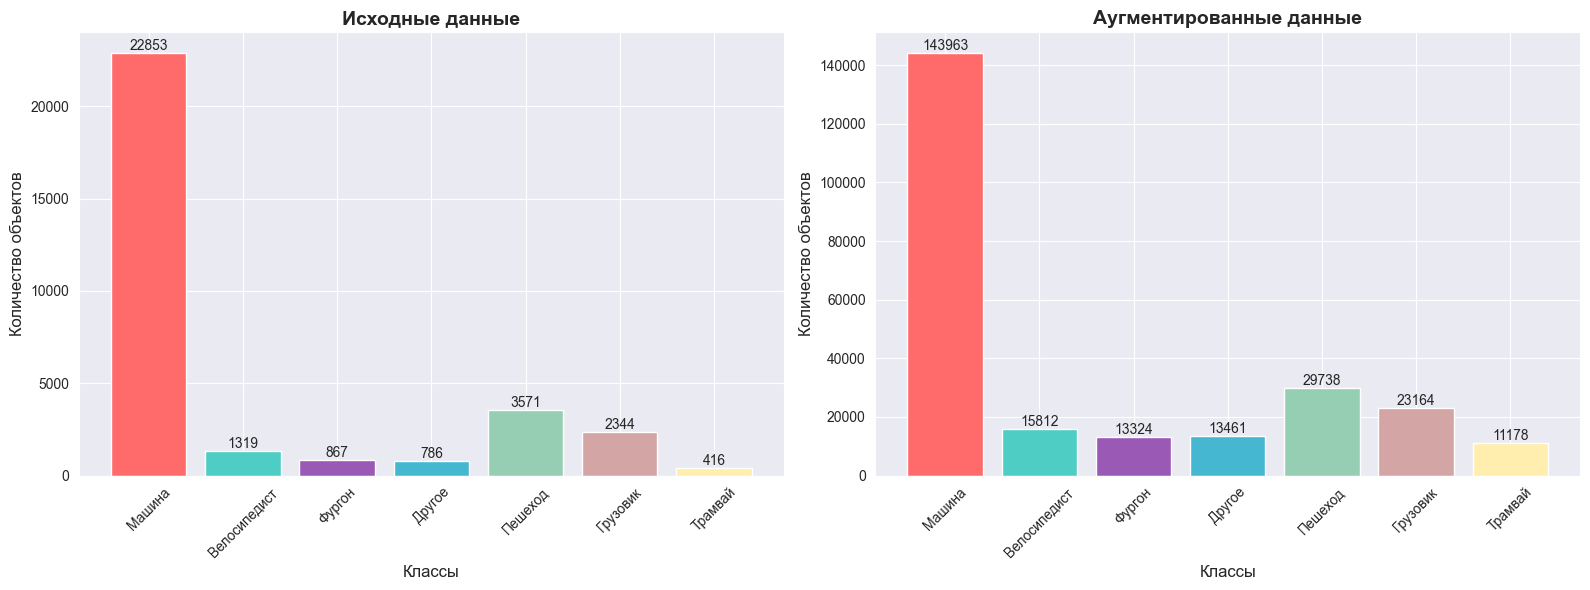


▶ Построение диаграммы с накоплением...
   График сохранен: data\kitti_for_yolo\plots\02_stacked_distribution.png


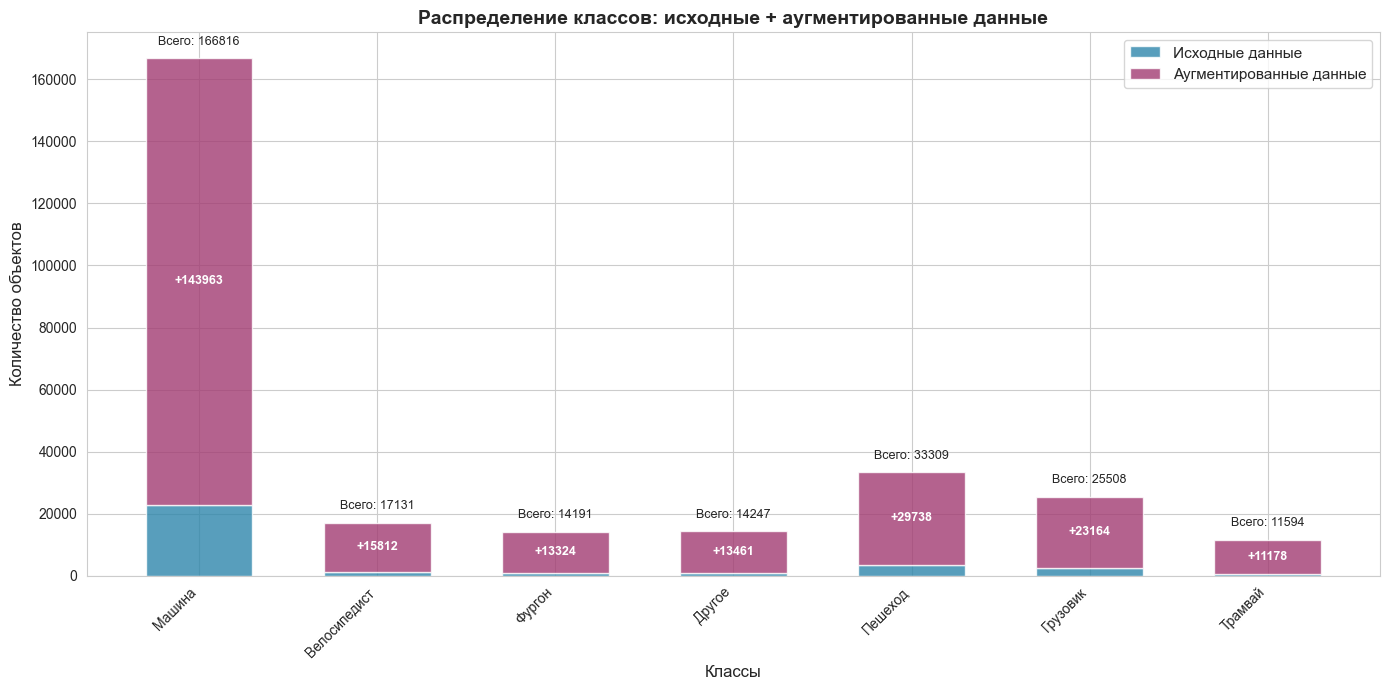


▶ Построение круговой диаграммы...
   График сохранен: data\kitti_for_yolo\plots\03_percentage_distribution.png


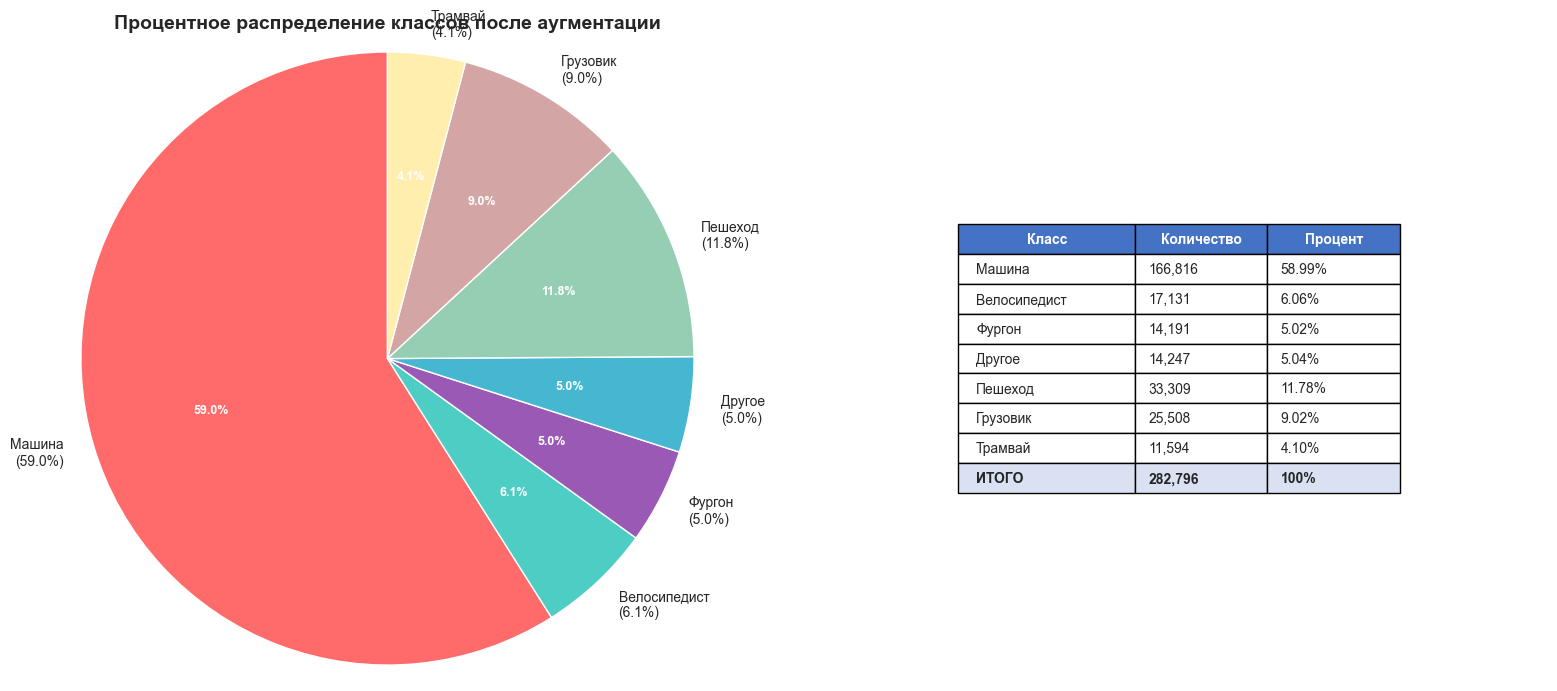


✅ Все графики сохранены в папке: data\kitti_for_yolo\plots

📈 КРАТКАЯ СВОДКА:
   Исходные данные: 32,156 объектов
   Аугментированные: 250,640 объектов
   Всего: 282,796 объектов
   Увеличение: +250,640 объектов (779.5%)


In [16]:
DATASET_PATH = "data/kitti_for_yolo"

print("="*70)
print("ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ КЛАССОВ KITTI")
print("="*70)
print(f"Датасет: {DATASET_PATH}")

# Создаем визуализатор
visualizer = DistributionVisualizer(DATASET_PATH)

# Получаем распределения
distributions = visualizer.get_all_distributions()

# Выводим статистику
visualizer.print_statistics(distributions)

print("\n" + "="*70)
print("ПОСТРОЕНИЕ ГРАФИКОВ")
print("="*70)

# Создаем папку для сохранения графиков
plots_path = Path(DATASET_PATH) / 'plots'
plots_path.mkdir(exist_ok=True)
print(f"Графики будут сохранены в: {plots_path}")

# 1. Сравнительная гистограмма (исходные vs аугментированные)
print("\n▶ Построение сравнительной гистограммы...")
visualizer.plot_distribution_comparison(
    distributions,
    plots_path / '01_original_vs_augmented.png'
)

# 2. Столбчатая диаграмма с накоплением
print("\n▶ Построение диаграммы с накоплением...")
visualizer.plot_stacked_distribution(
    distributions,
    plots_path / '02_stacked_distribution.png'
)

# 3. Круговая диаграмма
print("\n▶ Построение круговой диаграммы...")
visualizer.plot_percentage_distribution(
    distributions,
    plots_path / '03_percentage_distribution.png'
)

print(f"\n✅ Все графики сохранены в папке: {plots_path}")

# Выводим краткую сводку
print("\n📈 КРАТКАЯ СВОДКА:")
original_total = sum(distributions['original'].values())
aug_total = sum(distributions['augmented'].values())
total = sum(distributions['total'].values())

print(f"   Исходные данные: {original_total:,} объектов")
print(f"   Аугментированные: {aug_total:,} объектов")
print(f"   Всего: {total:,} объектов")
if original_total > 0:
    print(f"   Увеличение: +{aug_total:,} объектов ({aug_total/original_total*100:.1f}%)")

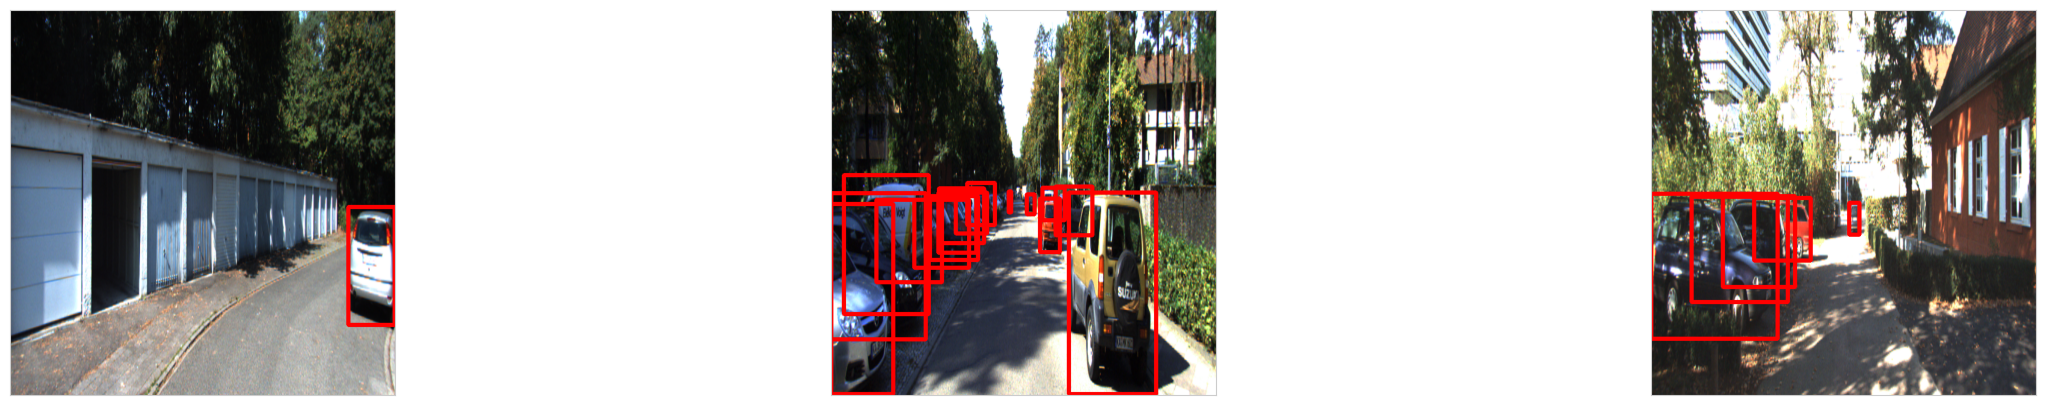

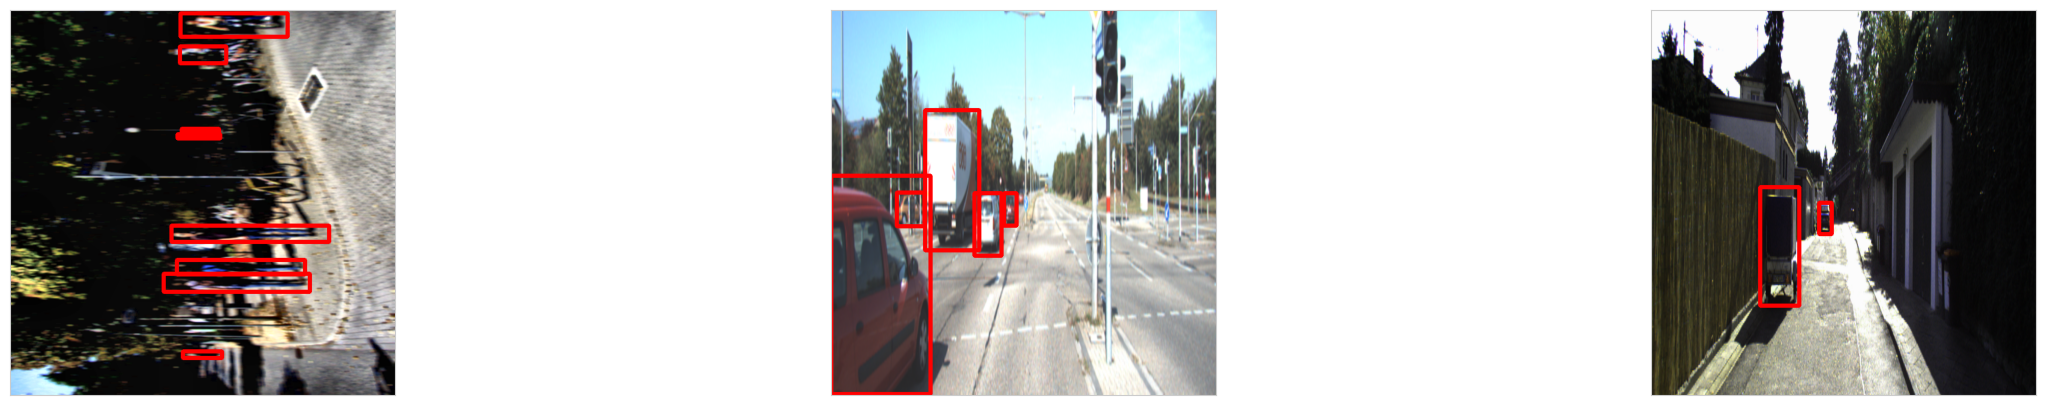

In [17]:
# ============================================
# 10. СОЗДАНИЕ DATALOADER И ВИЗУАЛИЗАЦИЯ
# ============================================

class KittiDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.img_names = os.listdir(img_dir)

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_names[idx])
        label_path = os.path.join(self.label_dir, self.img_names[idx].replace(".png", ".txt"))

        # Загрузка изображения
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Загрузка аннотаций
        labels = []
        boxes = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    class_id, x_center, y_center, width, height = map(float, line.split())
                    boxes.append([x_center, y_center, width, height])
                    labels.append(int(class_id))

        # Применение трансформаций
        if self.transform:
            transformed = self.transform(
                image=image,
                bboxes=boxes,
                class_labels=labels
            )
            image = transformed['image']
            boxes = transformed['bboxes']
            labels = transformed['class_labels']

        # Подготовка целевых тензоров для YOLOv8n_base
        targets = torch.zeros((len(boxes), 5), dtype=torch.float32)
        for i, (box, label) in enumerate(zip(boxes, labels)):
            targets[i, 0] = label
            targets[i, 1:] = torch.tensor(box)

        return image, targets
    
    

def collate_fn(batch):
    """Обработка батча с разным количеством объектов на изображении"""
    images, targets = zip(*batch)
    images = [torch.from_numpy(img) if isinstance(img, np.ndarray) else img for img in images]
    images = torch.stack([img.float() for img in images])
    return images, targets

batch_size = 3
img_size = 640

# Трансформации
train_transform = A.Compose([
    A.Resize(img_size, img_size),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Blur(blur_limit=3, p=0.1),
    A.Normalize(mean=[0, 0, 0], std=[1, 1, 1]),
    ToTensorV2()
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

test_transform = A.Compose([
    A.Resize(img_size, img_size),
    A.Normalize(mean=[0, 0, 0], std=[1, 1, 1]),
    ToTensorV2()
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))


# Создание датасетов
train_dataset = KittiDataset(
    img_dir=os.path.join(OUTPUT_IMAGE_DIR, "train"),
    label_dir=os.path.join(OUTPUT_LABEL_DIR, "train"),
    transform=train_transform)

test_dataset = KittiDataset(
    img_dir=os.path.join(OUTPUT_IMAGE_DIR, "val"),
    label_dir=os.path.join(OUTPUT_LABEL_DIR, "val"),
    transform=test_transform)

train_dataset_aug = KittiDataset(
    img_dir=os.path.join(OUTPUT_IMAGE_DIR, "train/augmented"),
    label_dir=os.path.join(OUTPUT_LABEL_DIR, "train/augmented"),
    transform=train_transform)


# Создание DataLoader'ов
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0)

# Визуализация одного батча
images, targets = next(iter(train_loader))
fig, axes = plt.subplots(ncols=len(images), squeeze=False, figsize=(30, 5))
for i in range(len(images)):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 255).astype(np.uint8)
    boxes = targets[i][:, 1:].numpy()
    img_ = img.copy()

    # Денормализация координат для отображения
    h, w = img.shape[:2]
    boxes[:, [0, 2]] *= w
    boxes[:, [1, 3]] *= h

    # Рисуем боксы
    for box in boxes:
        x, y, w, h = box
        x1 = int((x - w/2))
        y1 = int((y - h/2))
        x2 = int((x + w/2))
        y2 = int((y + h/2))
        cv2.rectangle(img_, (x1, y1), (x2, y2), (255, 0, 0), 5)
    axes[0, i].imshow(img_)
    axes[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

# Визуализация одного батча с аугментацией
images, targets = next(iter(train_loader_aug))
fig, axes = plt.subplots(ncols=len(images), squeeze=False, figsize=(30, 5))
for i in range(len(images)):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 255).astype(np.uint8)
    boxes = targets[i][:, 1:].numpy()
    img_ = img.copy()

    # Денормализация координат для отображения
    h, w = img.shape[:2]
    boxes[:, [0, 2]] *= w
    boxes[:, [1, 3]] *= h

    # Рисуем боксы
    for box in boxes:
        x, y, w, h = box
        x1 = int((x - w/2))
        y1 = int((y - h/2))
        x2 = int((x + w/2))
        y2 = int((y + h/2))
        cv2.rectangle(img_, (x1, y1), (x2, y2), (255, 0, 0), 5)
    axes[0, i].imshow(img_)
    axes[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])